<a href="https://colab.research.google.com/github/cubesugar173-crypto/Quant/blob/main/260915_Quant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
#!pip install fredapi
from fredapi import Fred
from dotenv import load_dotenv
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from google.colab import userdata

In [3]:
#api key
from pathlib import Path
from dotenv import load_dotenv


In [10]:
#fred = Fred(api_key=os.environ["FRED_API_KEY"])
fred= Fred(api_key=userdata.get("FRED_API_KEY"))

START = "2020-01-01"
TICKERS = ["SPY", "QQQ", "RKLB", "NVDA", "UFO", "SOXL", "AMD", "DECK"]        # 원하시는 종목/ETF로 바꾸세요

FRED_SERIES = {
    "vix":    "VIXCLS",         # 변동성지수
    "ust10y": "DGS10",          # 10년 국채
    "ust2y":  "DGS2",           # 2년 국채
    "curve":  "T10Y2Y",         # 장단기 금리차
    "baa10y": "BAA10Y",         # hy_oas 대체: 무디스 Baa - 10Y, 일별 장기 시계열
    "dxy":    "DTWEXBGS",       # 달러 인덱스
}

In [7]:
#주가받기
raw = yf.download(TICKERS, start=START, auto_adjust=True, progress=False) #auto adujust:수정주가
print(raw.shape)
raw.head(3)

(1687, 40)


Price           Close                                                   \
Ticker            AMD       DECK      NVDA         QQQ RKLB       SOXL   
Date                                                                     
2020-01-02  49.099998  28.695000  5.957138  208.088882  NaN  18.842724   
2020-01-03  48.599998  28.910000  5.861788  206.182785  NaN  17.824947   
2020-01-06  48.389999  29.083332  5.886371  207.511292  NaN  17.259590   

Price                                   High             ...        Open  \
Ticker             SPY        UFO        AMD       DECK  ...         SPY   
Date                                                     ...               
2020-01-02  295.391754  24.236860  49.250000  28.701668  ...  294.182449   
2020-01-03  293.154938  24.381777  49.389999  28.945000  ...  292.018361   
2020-01-06  294.273376  24.389931  48.860001  29.123333  ...  291.409181   

Price                    Volume                                               \
Ticker            UFO       AMD     DECK       NVDA       QQQ RKLB      SOXL   
Date                                                                           
2020-01-02  23.992318  80331100  1627200  237536000  30969400  NaN  10438500   
2020-01-03  24.028550  73127400  1890600  205384000  27518900  NaN  14713500   
2020-01-06  24.571977  47934900  1774800  262636000  21655300  NaN  11313000   

Price                        
Ticker           SPY    UFO  
Date                         
2020-01-02  59151200  19300  
2020-01-03  77709700  19200  
2020-01-06  55653900  12900  

[3 rows x 40 columns]

In [8]:
#컬럼 평탄화
px = raw.stack(level="Ticker", future_stack=True).reset_index()
px.columns = [c.lower() for c in px.columns]

prices = px.pivot(index="date", columns="ticker")
prices.columns = [f"{t}_{f}" for f, t in prices.columns]
prices.index = pd.to_datetime(prices.index).tz_localize(None) #시간대 정보 떼기
prices = prices.sort_index()

print(prices.shape)
prices.head(3)

(1687, 40)


,AMD_close,DECK_close,NVDA_close,QQQ_close,RKLB_close,SOXL_close,SPY_close,UFO_close,AMD_high,DECK_high,...,SPY_open,UFO_open,AMD_volume,DECK_volume,NVDA_volume,QQQ_volume,RKLB_volume,SOXL_volume,SPY_volume,UFO_volume
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,49.099998,28.695000,5.957138,208.088882,NaN,18.842724,295.391754,24.236860,49.250000,28.701668,...,294.182449,23.992318,80331100.0,1627200.0,237536000.0,30969400.0,NaN,10438500.0,59151200.0,19300.0
2020-01-03,48.599998,28.910000,5.861788,206.182785,NaN,17.824947,293.154938,24.381777,49.389999,28.945000,...,292.018361,24.028550,73127400.0,1890600.0,205384000.0,27518900.0,NaN,14713500.0,77709700.0,19200.0
2020-01-06,48.389999,29.083332,5.886371,207.511292,NaN,17.259590,294.273376,24.389931,48.860001,29.123333,...,291.409181,24.571977,47934900.0,1774800.0,262636000.0,21655300.0,NaN,11313000.0,55653900.0,12900.0


In [11]:
#FRED받기
macro = pd.DataFrame({
    name: fred.get_series(sid, observation_start=START)
    for name, sid in FRED_SERIES.items()
})
macro.index = pd.to_datetime(macro.index)

print(macro.shape)
print(macro.isna().mean().round(3))   # 결측률 확인
macro.tail(3)

(1753, 6)
vix       0.019
ust10y    0.042
ust2y     0.042
curve     0.042
baa10y    0.044
dxy       0.045
dtype: float64


,vix,ust10y,ust2y,curve,baa10y,dxy
2026-09-16,17.71,5.01,4.74,0.27,1.43,NaN
2026-09-17,15.44,4.94,4.67,0.27,1.44,NaN
2026-09-18,NaN,NaN,NaN,0.25,NaN,NaN


In [ ]:
#합치기

df = prices.join(macro.reindex(prices.index).ffill())

print("shape:", df.shape)
print("결측 있는 컬럼:", df.columns[df.isna().any()].tolist())
df.head(3)

shape: (1687, 46)
결측 있는 컬럼: ['RKLB_close', 'RKLB_high', 'RKLB_low', 'RKLB_open', 'RKLB_volume']


,AMD_close,DECK_close,NVDA_close,QQQ_close,RKLB_close,SOXL_close,SPY_close,UFO_close,AMD_high,DECK_high,...,RKLB_volume,SOXL_volume,SPY_volume,UFO_volume,vix,ust10y,ust2y,curve,baa10y,dxy
date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,49.099998,28.695000,5.957138,208.088821,NaN,18.842726,295.391815,24.236860,49.250000,28.701668,...,NaN,10438500.0,59151200.0,19300.0,12.47,1.88,1.58,0.30,1.98,114.9745
2020-01-03,48.599998,28.910000,5.861788,206.182785,NaN,17.824945,293.154999,24.381779,49.389999,28.945000,...,NaN,14713500.0,77709700.0,19200.0,14.02,1.80,1.53,0.27,1.99,114.9867
2020-01-06,48.389999,29.083332,5.886371,207.511246,NaN,17.259586,294.273407,24.389925,48.860001,29.123333,...,NaN,11313000.0,55653900.0,12900.0,13.85,1.81,1.54,0.27,2.02,114.9557


In [ ]:
#save
df.to_parquet("raw_daily.parquet")

In [ ]:
#여기부터 데이터 검증을 위한 시각화

In [ ]:
#설정&데이터 로드
plt.rcParams["font.family"] = "AppleGothic"   # 맥에서 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False    # 이거 없으면 마이너스가 □로 나옴
plt.rcParams["figure.figsize"] = (11, 4)

df = pd.read_parquet("raw_daily.parquet")

close = df[[c for c in df.columns if c.endswith("_close")]]
rets = np.log(close).diff()
macro = df[["vix", "ust10y", "curve", "baa10y", "dxy"]]

In [ ]:
#데이터 검증

print("기간:", df.index[0].date(), "~", df.index[-1].date(), f"({len(df)}일)")
print("\n결측:\n", df.isna().sum()[lambda s: s > 0].to_string() or "없음")

# 하루 ±15%는 실제로 드뭅니다. 많이 잡히면 수정주가 문제를 의심하세요.
print("\n±15% 초과일:")
for c in rets.columns:
    hits = rets[c].abs() > 0.15
    if hits.any():
        print(f"  {c}: {hits.sum()}일 →", rets[c][hits].round(3).to_dict())

기간: 2020-01-02 ~ 2026-09-18 (1687일)

결측:
 RKLB_close     227
RKLB_high      227
RKLB_low       227
RKLB_open      227
RKLB_volume    227

±15% 초과일:
  AMD_close: 6일 → {Timestamp('2020-03-12 00:00:00'): -0.158, Timestamp('2020-07-24 00:00:00'): 0.153, Timestamp('2025-04-09 00:00:00'): 0.214, Timestamp('2025-10-06 00:00:00'): 0.213, Timestamp('2026-02-04 00:00:00'): -0.19, Timestamp('2026-05-06 00:00:00'): 0.171}
  DECK_close: 10일 → {Timestamp('2020-03-12 00:00:00'): -0.157, Timestamp('2020-03-16 00:00:00'): -0.152, Timestamp('2020-03-18 00:00:00'): -0.194, Timestamp('2020-03-24 00:00:00'): 0.16, Timestamp('2023-10-27 00:00:00'): 0.173, Timestamp('2025-01-31 00:00:00'): -0.229, Timestamp('2025-04-03 00:00:00'): -0.157, Timestamp('2025-05-23 00:00:00'): -0.221, Timestamp('2025-10-24 00:00:00'): -0.165, Timestamp('2026-01-30 00:00:00'): 0.178}
  NVDA_close: 6일 → {Timestamp('2020-03-16 00:00:00'): -0.204, Timestamp('2020-03-24 00:00:00'): 0.158, Timestamp('2023-05-25 00:00:00'): 0.218, Times

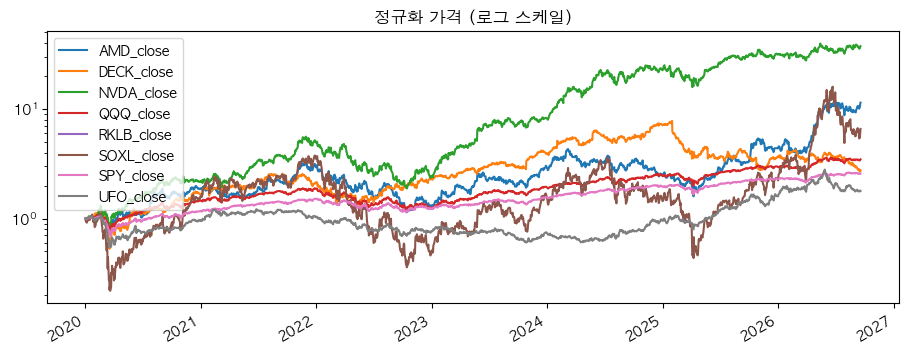

In [ ]:
#가격 추이
ax = (close / close.iloc[0]).plot(logy=True, title="정규화 가격 (로그 스케일)")
ax.set_xlabel("")
plt.show()

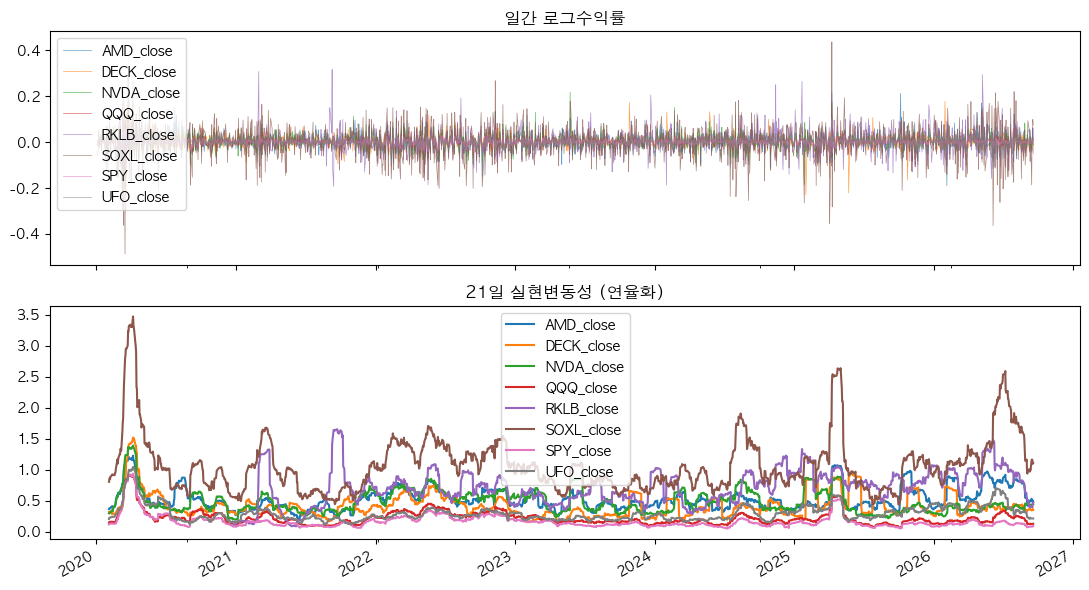

In [ ]:
#수익률과 변동성 군집
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

rets.plot(ax=ax[0], lw=0.5, alpha=0.7, title="일간 로그수익률")
rets.rolling(21).std().mul(np.sqrt(252)).plot(ax=ax[1], title="21일 실현변동성 (연율화)")
ax[1].set_xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
#매크로 시리즈-알려진 사건이 보이느지 확인
'''
fig, ax = plt.subplots(2, 2, figsize=(11, 6))
macro["vix"].plot(ax=ax[0, 0], title="VIX")
macro["hy_oas"].plot(ax=ax[0, 1], title="하이일드 스프레드")
macro["curve"].plot(ax=ax[1, 0], title="장단기 금리차 (10Y-2Y)")
macro["dxy"].plot(ax=ax[1, 1], title="달러 인덱스")
for a in ax.flat:
    a.set_xlabel("")
plt.tight_layout()
plt.show()
'''
price_cols = [c for c in prices.columns]
macro_aligned = macro.reindex(prices.index).ffill()

df = prices.join(macro_aligned)          # 가격 NaN은 절대 채우지 않는다

print("매크로 결측:", df[macro.columns].isna().sum().sum())
print("\n종목별 데이터 시작일:")
for t in ["AMD", "DECK", "NVDA", "RKLB", "SOXL"]:
    s = df[f"{t}_close"].dropna()
    print(f"  {t}: {s.index[0].date()}  ({len(s)}일)")

매크로 결측: 0

종목별 데이터 시작일:
  AMD: 2020-01-02  (1687일)
  DECK: 2020-01-02  (1687일)
  NVDA: 2020-01-02  (1687일)
  RKLB: 2020-11-24  (1460일)
  SOXL: 2020-01-02  (1687일)


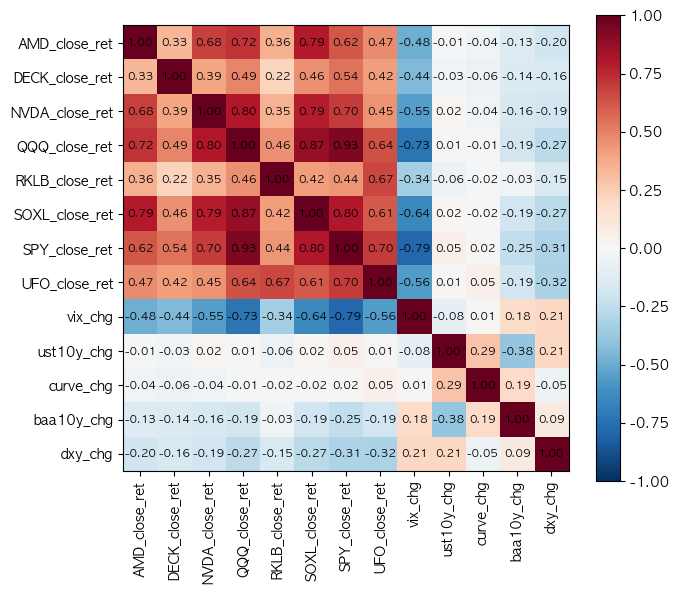

In [ ]:
#상관관계
X = pd.concat([rets.add_suffix("_ret"), macro.diff().add_suffix("_chg")], axis=1)
corr = X.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.show()